# Bound Definition Test: First-Crossing Consistency

## Background

Our bound estimate for each trial uses the pigeon's position at the NDT lag steps before the response.
The core assumption is that the decision ended the **first** time the pigeon crossed the decision
threshold — and that the position at the defined NDT crossing point reflects that first crossing.

## Analyses

**Part 1 – Premature crossings (original):**  
For each trial, check whether the pigeon's position already exceeded the inferred bound before
the defined NDT crossing. Report per-subject fraction vs mean RT, by block.

**Part 2 – Direction of motion at the crossing:**  
A decision that terminates at a bound crossing should show the pigeon *moving toward* the choice
side at the crossing. We measure the fraction of trials where the pigeon is instead moving backward
at the current NDT crossing, and ask whether that fraction is correlated with the premature-crossing
fraction.

**Part 3 – Congruence profiles with and without the direction constraint:**  
Standard congruence asks only whether the position at lag *k* matches the choice. Joint
(positional + directional) congruence additionally requires the pigeon to be moving toward
the choice side. We plot both profiles by lag to see whether adding the direction constraint
shifts the optimal lag.

**Part 4 – Refined crossing definition and its effects:**  
For trials where the pigeon is moving *backward* at the current NDT crossing, we search backward
through the trial for the most recent step at which the pigeon (a) was at or above the current
bound and (b) was moving toward the choice side. We use that as a refined crossing, compare the
resulting bound magnitudes, and measure how much the premature-crossing fraction changes.

**Part 5 – Peak-step bound definition:**  
An alternative to Part 4: when the pigeon is moving backward at the current NDT crossing, replace
the midpoint with `steps[t_curr-1]` — the earlier, outermost of the two crossing steps. This
keeps the crossing time fixed but raises the bound estimate to the pigeon's peak excursion for
backward-motion trials. Same analyses as Part 4: bound magnitude change and premature-crossing
fraction change.

**Part 6 – Congruence comparison across three bound definitions:**  
Direct comparison of per-subject congruence (fraction of trials where the bound estimate has the
correct sign relative to choice) across three definitions:
- **Def 1 – Basic midpoint**: `(steps[t_curr−1] + steps[t_curr]) / 2` for every trial
- **Def 2 – Peak-step** (Part 5): midpoint for forward trials; `steps[t_curr−1]` for backward trials
- **Def 3 – Refined crossing** (Part 4): midpoint for forward trials; midpoint at the most recent
  earlier forward crossing for backward trials (NaN when no such crossing exists)

For each of the first three OL blocks, scatter plots compare Def 1 vs Def 2 and Def 1 vs Def 3,
one point per subject. The definition that consistently sits above the identity line should be
used for all other analyses.

*Note:* All three congruences are computed from raw (non-bias-corrected) step positions, so the
comparison reflects only the geometric choice of crossing estimate. Def 3 per-subject means
exclude backward trials with no recoverable forward crossing, so its mean is computed over a
slightly smaller trial set than Def 1 and Def 2.

**Part 7 – Incongruence as a function of decision time:**  
For each subject and each integer DT value, count the number of incongruent trials (basic
midpoint sign ≠ choice) and the incongruent rate. Scatter both against DT, with mean ± SEM
across subjects overlaid, separately for each OL block.

**Part 8 – Bound magnitude and incongruence:**  
Three per-subject analyses of how bound magnitude relates to congruence (OL, blocks 1–3):
1. Scatter of fraction congruent vs mean bound (peak-step, bias-corrected) — one point per participant.
2. Scatter of mean |basic midpoint| on incongruent vs congruent trials — one point per participant;
   below the diagonal means incongruent trials had smaller bound magnitude.
3. Incongruent fraction (basic midpoint) vs peak-step bound in actual value bins (0.05 wide) —
   each participant contributes one point per bin; mean ± SEM line overlaid.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.dirname(os.getcwd()))
from pigeon.data import get_data_table, get_good_trial_array

MAX_NDT   = 5
LAGS      = np.arange(MAX_NDT)
TASK_LIST = ('OL', 'MX')

In [2]:
def compute_trial_props(row):
    """
    Compute per-trial bound-crossing diagnostics.

    NDT crossing is between steps[t_curr-1] and steps[t_curr],
    where t_curr = RT - 1 - ndt_lag (= DT, the decision-time step index).

    Returns a dict with:
      early_crossing      : bool  — any pre-crossing step exceeded |bound| in choice dir
      direction_forward   : bool  — pigeon was moving toward choice at the current crossing
      has_alt_crossing    : bool  — a refined forward crossing was found (or current IS forward)
      abs_bound_alt       : float — |bound| at the refined crossing (Part 4)
      early_crossing_alt  : bool  — premature crossing relative to the refined crossing (Part 4)
      abs_bound_peak      : float — |bound| under peak-step definition (Part 5)
      early_crossing_peak : bool  — premature crossing under peak-step definition (Part 5)
      cong_basic          : float — congruence under basic midpoint definition (Def 1)
      cong_peak           : float — congruence under peak-step definition (Def 2)
      cong_refined        : float — congruence under refined crossing definition (Def 3);
                                    NaN when the pigeon is backward AND no earlier forward
                                    crossing above the bound exists in the trial
    """
    steps = row['steps']
    bound = row['bound']
    RT, DT = row['RT'], row['DT']

    out = dict(early_crossing=np.nan, direction_forward=np.nan,
               has_alt_crossing=np.nan, abs_bound_alt=np.nan,
               early_crossing_alt=np.nan,
               abs_bound_peak=np.nan, early_crossing_peak=np.nan,
               cong_basic=np.nan, cong_peak=np.nan, cong_refined=np.nan)

    if (steps is None or len(steps) == 0
            or not np.isfinite(bound) or bound == 0
            or not np.isfinite(RT) or not np.isfinite(DT)):
        return out

    RT = int(RT);  DT = int(DT)
    ndt_lag = RT - DT - 1
    abs_b   = np.abs(bound)
    sgn     = np.sign(bound)
    sc      = steps[np.isfinite(steps)]
    if len(sc) < RT:
        return out

    t_curr  = RT - 1 - ndt_lag   # step index of later step in the crossing midpoint
    pre_end = t_curr - 1          # steps[0:pre_end] are strictly before the crossing

    # ── Early crossing (current definition) ──────────────────────────────────
    out['early_crossing'] = (
        bool(np.any(sc[:pre_end] * sgn >= abs_b)) if pre_end > 0 else False
    )

    # ── Direction at current crossing ─────────────────────────────────────────
    if t_curr < 1:
        return out
    step_in = sc[t_curr] - sc[t_curr - 1]
    fwd     = bool(step_in * sgn > 0)
    out['direction_forward'] = fwd

    # ── Raw midpoint (basic / Def 1) ──────────────────────────────────────────
    # Uses the two raw step positions at the NDT crossing window, with no
    # peak-step correction or bias correction applied.
    raw_mid = (sc[t_curr - 1] + sc[t_curr]) / 2

    # ── Per-definition congruence (Defs 1–3) ─────────────────────────────────
    # All three use raw step positions (not bias-corrected) so the comparison
    # is purely about the geometric definition of the crossing estimate.
    choice = row['choice']
    choice_pm = None
    if np.isfinite(choice):
        choice_pm = int(2 * int(choice) - 1)          # +1 = right, -1 = left

        # Def 1: sign of the basic midpoint
        out['cong_basic'] = float(np.sign(raw_mid) == choice_pm)

        # Def 2: for backward trials, use sc[t_curr-1] (the earlier/outermost step);
        # for forward trials, the midpoint and peak step agree in sign so either works.
        peak_val = raw_mid if fwd else sc[t_curr - 1]
        out['cong_peak'] = float(np.sign(peak_val) == choice_pm)

    # ── Peak-step bound (Part 5) ──────────────────────────────────────────────
    # For backward-motion trials: replace the midpoint with steps[t_curr-1], the
    # first/earlier of the two crossing steps, which is furthest from centre.
    # For forward-motion trials: peak bound == current midpoint bound (no change).
    peak_b = abs_b if fwd else np.abs(sc[t_curr - 1])
    out['abs_bound_peak']      = peak_b
    out['early_crossing_peak'] = (
        bool(np.any(sc[:pre_end] * sgn >= peak_b)) if pre_end > 0 else False
    )

    if fwd:
        # Current crossing is already forward — no refinement needed (Part 4)
        out['has_alt_crossing']   = True
        out['abs_bound_alt']      = abs_b
        out['early_crossing_alt'] = out['early_crossing']
        if choice_pm is not None:
            out['cong_refined'] = out['cong_basic']   # forward: all three defs agree
        return out

    # ── Backward at current crossing: find last forward crossing before t_curr ─
    for t in range(t_curr - 1, 0, -1):
        if sc[t] * sgn >= abs_b and (sc[t] - sc[t - 1]) * sgn > 0:
            # Keep the signed midpoint so we can test congruence correctly;
            # abs_bound_alt stores the magnitude for the Part 4 bound-change analyses.
            alt_mid_signed = (sc[t - 1] + sc[t]) / 2
            alt_b          = np.abs(alt_mid_signed)
            pre_alt        = t - 1
            out['has_alt_crossing']   = True
            out['abs_bound_alt']      = alt_b
            out['early_crossing_alt'] = (
                bool(np.any(sc[:pre_alt] * sgn >= alt_b)) if pre_alt > 0 else False
            )
            if choice_pm is not None:
                # Use the actual signed midpoint — NOT sgn*alt_b, which would
                # always give sign(sgn) and make cong_refined identical to cong_peak.
                out['cong_refined'] = float(np.sign(alt_mid_signed) == choice_pm)
            return out

    out['has_alt_crossing'] = False
    # No alt crossing: refined congruence is undefined for this trial (NaN).
    # The per-subject mean of cong_refined therefore excludes these trials,
    # so it is computed over a smaller trial set than cong_basic / cong_peak.
    return out


def lag_congruence_profiles(dg, max_ndt=MAX_NDT, min_n=20):
    """
    For each NDT lag k compute:
      pos_c   : P(sign(bound_k) == choice)                  — position congruence
      dir_c   : P(sign(step_dir_k) == choice)               — direction congruence
      joint_c : P(sign(bound_k)==choice AND step_dir_k==choice) — joint congruence
    where bound_k = midpoint of steps[RT-1-k] and steps[RT-2-k],
          step_dir_k = steps[RT-1-k] - steps[RT-2-k].
    """
    choices_pm = dg['choice'].values.astype(float) * 2 - 1
    steps_arr  = dg['steps'].values
    rt_arr     = dg['RT'].values
    n          = len(dg)

    pos_c   = np.full(max_ndt, np.nan)
    dir_c   = np.full(max_ndt, np.nan)
    joint_c = np.full(max_ndt, np.nan)

    for k in range(max_ndt):
        bounds_k = np.full(n, np.nan)
        dirs_k   = np.full(n, np.nan)
        for i, (s, rt) in enumerate(zip(steps_arr, rt_arr)):
            if s is None or not np.isfinite(rt):
                continue
            rt_int = int(rt)
            sc = s[np.isfinite(s)]
            if len(sc) >= rt_int and rt_int >= k + 2:
                bounds_k[i] = (sc[rt_int - 1 - k] + sc[rt_int - 2 - k]) / 2
                dirs_k[i]   =  sc[rt_int - 1 - k] - sc[rt_int - 2 - k]

        valid = np.isfinite(bounds_k) & np.isfinite(dirs_k) & np.isfinite(choices_pm)
        if valid.sum() < min_n:
            continue
        pm    = choices_pm[valid].astype(int)
        pos_m = np.sign(bounds_k[valid]).astype(int) == pm
        dir_m = np.sign(dirs_k[valid]).astype(int)   == pm
        pos_c[k]   = pos_m.mean()
        dir_c[k]   = dir_m.mean()
        joint_c[k] = (pos_m & dir_m).mean()

    return pos_c, dir_c, joint_c

In [3]:
datasets  = {}
summaries = {}

for task_type in TASK_LIST:
    df   = get_data_table(task_type=task_type, correct_bias=None)
    good = get_good_trial_array(df)
    dg   = df[good].copy()

    props_df = pd.DataFrame(dg.apply(compute_trial_props, axis=1).tolist(), index=dg.index)
    dg       = pd.concat([dg, props_df], axis=1)

    frac_ec   = dg['early_crossing'].mean(skipna=True)
    frac_bwd  = (dg['direction_forward'] == False).mean()
    frac_alt  = dg['has_alt_crossing'].mean(skipna=True)
    frac_ec_a = dg['early_crossing_alt'].mean(skipna=True)
    frac_ec_p = dg['early_crossing_peak'].mean(skipna=True)
    print(f"{task_type}: {good.sum():,} good trials | "
          f"premature: current={frac_ec:.3f}  alt={frac_ec_a:.3f}  peak={frac_ec_p:.3f} | "
          f"backward at crossing={frac_bwd:.3f} | alt crossing found={frac_alt:.3f}")

    datasets[task_type] = dg

    summary = (
        dg.groupby(['subject_index', 'block_index'])
        .agg(
            frac_early        = ('early_crossing',      'mean'),
            frac_early_alt    = ('early_crossing_alt',  'mean'),
            frac_early_peak   = ('early_crossing_peak', 'mean'),
            frac_backward     = ('direction_forward',   lambda x: (x == False).mean()),
            mean_rt           = ('RT',                  'mean'),
            n_trials          = ('early_crossing',      'count'),
            mean_cong_basic   = ('cong_basic',          'mean'),
            mean_cong_peak    = ('cong_peak',           'mean'),
            mean_cong_refined = ('cong_refined',        'mean'),
        )
        .reset_index()
    )
    summaries[task_type] = summary

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

## Part 1 – Premature crossings vs mean RT

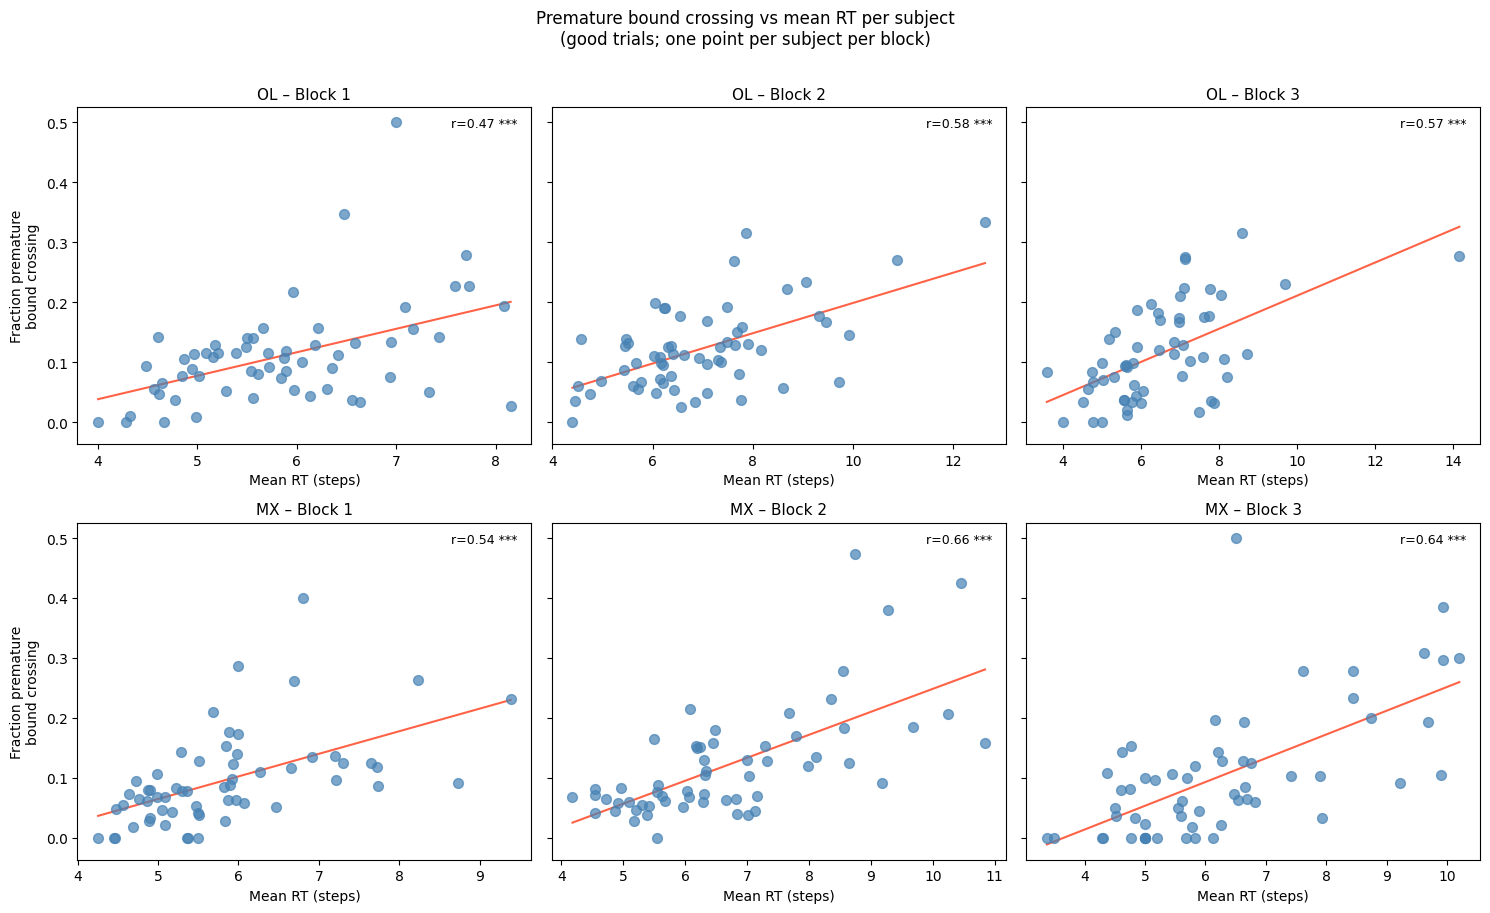

In [4]:
n_blocks   = 3
block_list = list(range(1, n_blocks + 1))

fig, axes = plt.subplots(2, n_blocks, figsize=(5 * n_blocks, 9), sharey=True)

for ti, task_type in enumerate(TASK_LIST):
    summary = summaries[task_type]
    for bi, block in enumerate(block_list):
        ax = axes[ti, bi]
        bd = summary[summary['block_index'] == block].dropna(subset=['frac_early', 'mean_rt'])
        ax.scatter(bd['mean_rt'], bd['frac_early'], color='steelblue', alpha=0.7, s=50, zorder=5)
        if len(bd) >= 3:
            sl, ic, r, p, _ = stats.linregress(bd['mean_rt'], bd['frac_early'])
            xf = np.linspace(bd['mean_rt'].min(), bd['mean_rt'].max(), 100)
            ax.plot(xf, sl * xf + ic, color='tomato', lw=1.5)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
            ax.text(0.97, 0.97, f'r={r:.2f} {sig}', transform=ax.transAxes,
                    fontsize=9, ha='right', va='top')
        ax.set_title(f'{task_type} – Block {block}', fontsize=11)
        ax.set_xlabel('Mean RT (steps)', fontsize=10)
        if bi == 0:
            ax.set_ylabel('Fraction premature\nbound crossing', fontsize=10)

fig.suptitle('Premature bound crossing vs mean RT per subject\n'
             '(good trials; one point per subject per block)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Part 2 – Direction of motion at the current NDT crossing

If the decision ends when the bound is crossed, the pigeon should be moving *toward* the choice
side at that moment. Here we measure the fraction of trials where direction is backward, and
ask whether backward-motion trials and premature-crossing trials are the same trials.

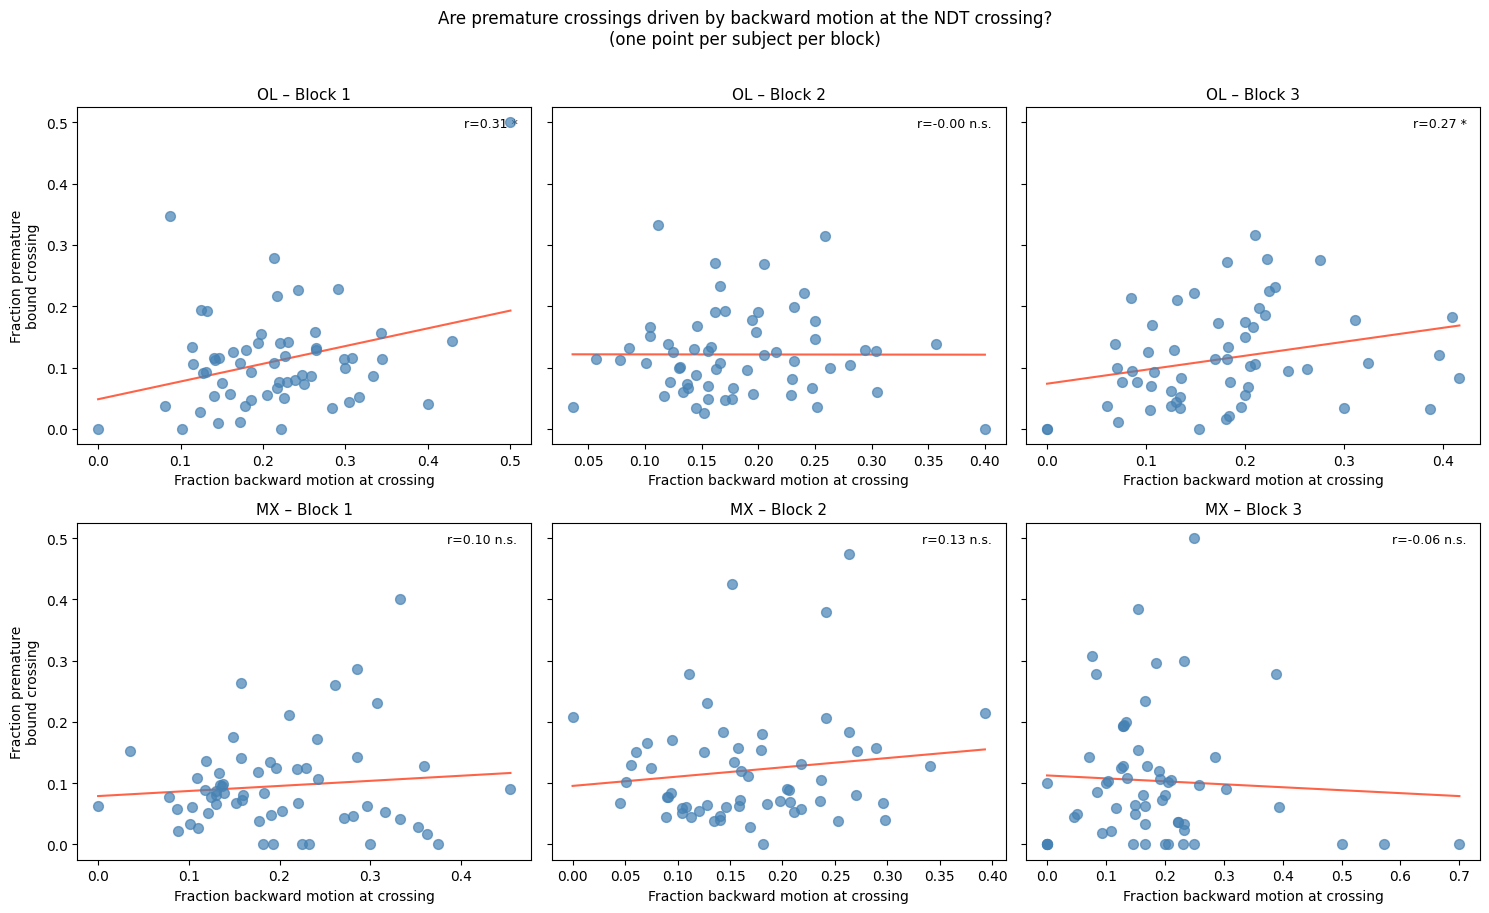

In [5]:
fig, axes = plt.subplots(2, n_blocks, figsize=(5 * n_blocks, 9), sharey=True)

for ti, task_type in enumerate(TASK_LIST):
    summary = summaries[task_type]
    for bi, block in enumerate(block_list):
        ax = axes[ti, bi]
        bd = summary[summary['block_index'] == block].dropna(
            subset=['frac_backward', 'frac_early'])
        ax.scatter(bd['frac_backward'], bd['frac_early'],
                   color='steelblue', alpha=0.7, s=50, zorder=5)
        if len(bd) >= 3:
            sl, ic, r, p, _ = stats.linregress(bd['frac_backward'], bd['frac_early'])
            xf = np.linspace(bd['frac_backward'].min(), bd['frac_backward'].max(), 100)
            ax.plot(xf, sl * xf + ic, color='tomato', lw=1.5)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
            ax.text(0.97, 0.97, f'r={r:.2f} {sig}', transform=ax.transAxes,
                    fontsize=9, ha='right', va='top')
        ax.set_title(f'{task_type} – Block {block}', fontsize=11)
        ax.set_xlabel('Fraction backward motion at crossing', fontsize=10)
        if bi == 0:
            ax.set_ylabel('Fraction premature\nbound crossing', fontsize=10)

fig.suptitle('Are premature crossings driven by backward motion at the NDT crossing?\n'
             '(one point per subject per block)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Part 3 – Congruence profiles: position-only vs joint (position + direction)

At each NDT lag *k*, we compute three quantities across all good trials:
- **Position congruence**: P(sign of midpoint bound == choice side)
- **Direction congruence**: P(step direction at lag *k* == choice side)
- **Joint congruence**: P(both position AND direction match choice)

The standard bound definition maximises position congruence to pick the NDT lag.
A direction-refined definition would maximise joint congruence — and may prefer a different lag.

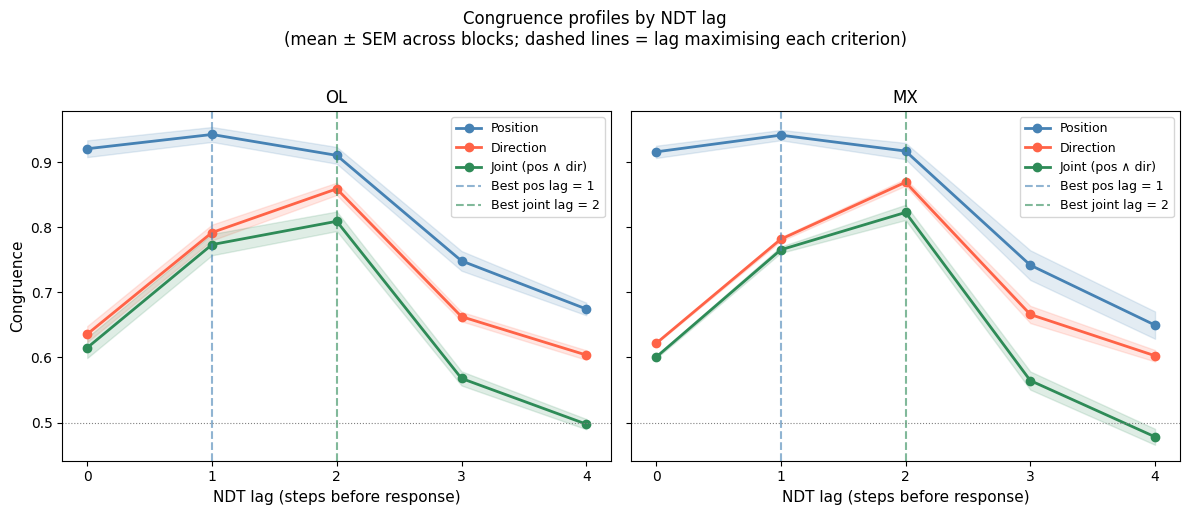

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = {'pos': 'steelblue', 'dir': 'tomato', 'joint': 'seagreen'}
labels = {'pos': 'Position', 'dir': 'Direction', 'joint': 'Joint (pos ∧ dir)'}

for ti, task_type in enumerate(TASK_LIST):
    ax  = axes[ti]
    dg  = datasets[task_type]

    # Compute profiles per block, then average
    block_profiles = {'pos': [], 'dir': [], 'joint': []}
    for block in block_list:
        sub = dg[dg['block_index'] == block]
        if len(sub) < 20:
            continue
        pc, dc, jc = lag_congruence_profiles(sub)
        block_profiles['pos'].append(pc)
        block_profiles['dir'].append(dc)
        block_profiles['joint'].append(jc)

    for key, color, label in [
        ('pos',   colors['pos'],   labels['pos']),
        ('dir',   colors['dir'],   labels['dir']),
        ('joint', colors['joint'], labels['joint']),
    ]:
        arr = np.array(block_profiles[key])   # shape (n_blocks, MAX_NDT)
        mn  = np.nanmean(arr, axis=0)
        se  = np.nanstd(arr, axis=0) / np.sqrt(np.sum(np.isfinite(arr), axis=0))
        ax.fill_between(LAGS, mn - se, mn + se, color=color, alpha=0.15)
        ax.plot(LAGS, mn, 'o-', color=color, lw=2, ms=6, label=label)

    # Mark lag chosen by each criterion
    pos_all  = np.nanmean(block_profiles['pos'],   axis=0)
    joint_all = np.nanmean(block_profiles['joint'], axis=0)
    best_pos   = int(np.nanargmax(pos_all))
    best_joint = int(np.nanargmax(joint_all))
    ax.axvline(best_pos,   color=colors['pos'],   lw=1.5, ls='--', alpha=0.6,
               label=f'Best pos lag = {best_pos}')
    ax.axvline(best_joint, color=colors['joint'], lw=1.5, ls='--', alpha=0.6,
               label=f'Best joint lag = {best_joint}')

    ax.axhline(0.5, color='gray', lw=0.8, ls=':')
    ax.set_xticks(LAGS)
    ax.set_xlabel('NDT lag (steps before response)', fontsize=11)
    if ti == 0:
        ax.set_ylabel('Congruence', fontsize=11)
    ax.set_title(f'{task_type}', fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Congruence profiles by NDT lag\n'
             '(mean ± SEM across blocks; dashed lines = lag maximising each criterion)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Part 4 – Refined crossing: bound changes and premature-crossing improvement

For trials where the pigeon was moving *backward* at the current NDT crossing, we substitute
the most recent *forward* crossing of the current bound threshold found by scanning backward
through the trial. We then ask:
1. How different is the refined bound magnitude from the current bound?
2. How much does the per-subject premature-crossing fraction change?

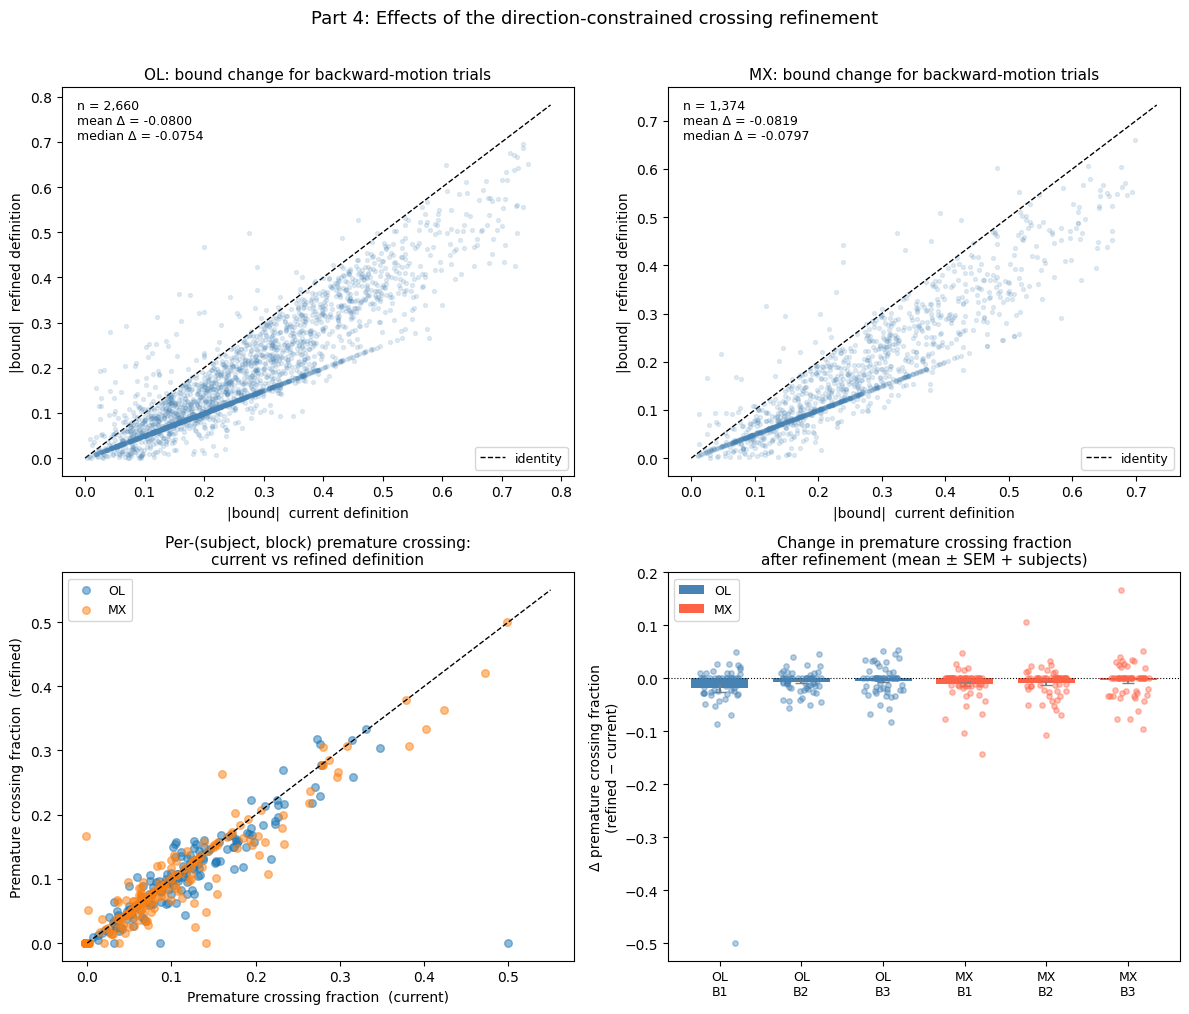

In [7]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panels (0,0) and (0,1): |bound_current| vs |bound_alt|, one panel per task ─
for ti, task_type in enumerate(TASK_LIST):
    ax = axes[0, ti]
    dg = datasets[task_type]

    # Only backward-motion trials where an alternative crossing was found
    mask = (dg['direction_forward'] == False) & (dg['has_alt_crossing'] == True)
    sub  = dg[mask].dropna(subset=['abs_bound_alt'])
    x    = sub['bound'].abs().values
    y    = sub['abs_bound_alt'].values

    ax.scatter(x, y, color='steelblue', alpha=0.15, s=8, zorder=5)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='identity')

    delta = y - x
    ax.text(0.03, 0.97,
            f'n = {len(sub):,}\nmean Δ = {delta.mean():+.4f}\nmedian Δ = {np.median(delta):+.4f}',
            transform=ax.transAxes, fontsize=9, va='top')

    ax.set_xlabel('|bound|  current definition', fontsize=10)
    ax.set_ylabel('|bound|  refined definition', fontsize=10)
    ax.set_title(f'{task_type}: bound change for backward-motion trials', fontsize=11)
    ax.legend(fontsize=9)

# ── Panel (1,0): per-subject-block scatter, frac_early vs frac_early_alt ────
ax = axes[1, 0]
for ti, task_type in enumerate(TASK_LIST):
    summary = summaries[task_type]
    bd = summary.dropna(subset=['frac_early', 'frac_early_alt'])
    jit = rng.uniform(-0.003, 0.003, size=len(bd))
    ax.scatter(bd['frac_early'] + jit, bd['frac_early_alt'],
               alpha=0.5, s=30, label=task_type)

all_vals = pd.concat(
    [summaries[t][['frac_early', 'frac_early_alt']].dropna() for t in TASK_LIST]
)
lim = max(all_vals.values.max(), 0.01) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Premature crossing fraction  (current)', fontsize=10)
ax.set_ylabel('Premature crossing fraction  (refined)', fontsize=10)
ax.set_title('Per-(subject, block) premature crossing:\ncurrent vs refined definition', fontsize=11)
ax.legend(fontsize=9)

# ── Panel (1,1): mean change in premature-crossing fraction by task and block ─
ax = axes[1, 1]
x_tick = 0
tick_positions, tick_labels = [], []
for ti, task_type in enumerate(TASK_LIST):
    summary = summaries[task_type]
    for block in block_list:
        bd = summary[summary['block_index'] == block].dropna(
            subset=['frac_early', 'frac_early_alt'])
        if bd.empty:
            continue
        delta = bd['frac_early_alt'].values - bd['frac_early'].values
        m, se = delta.mean(), stats.sem(delta)
        color = 'steelblue' if task_type == 'OL' else 'tomato'
        ax.bar(x_tick, m, yerr=se, color=color, width=0.7, capsize=4,
               ecolor='gray', label=task_type if block == 1 else '_')
        # Overlay individual subjects
        jit = rng.uniform(-0.25, 0.25, size=len(delta))
        ax.scatter(x_tick + jit, delta, color=color, alpha=0.4, s=15, zorder=5)
        tick_positions.append(x_tick)
        tick_labels.append(f'{task_type}\nB{block}')
        x_tick += 1

ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('Δ premature crossing fraction\n(refined − current)', fontsize=10)
ax.set_title('Change in premature crossing fraction\nafter refinement (mean ± SEM + subjects)',
             fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('Part 4: Effects of the direction-constrained crossing refinement',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Part 5 – Peak-step bound definition

An alternative to Part 4's backward-search approach: when the pigeon is moving *backward* at
the current NDT crossing (between `steps[t_curr-1]` and `steps[t_curr]`), replace the midpoint
with `steps[t_curr-1]` — the earlier, outermost of the two steps.

**Rationale:** if the pigeon crossed the bound and is now retreating, the true peak excursion
(and best estimate of the threshold) is where it turned around, not the midpoint of its retreat.
This keeps the crossing time unchanged but raises the bound estimate for backward-motion trials
to the furthest position the pigeon reached at that crossing window.

Same analyses as Part 4:
1. How much does |bound| change for affected trials?
2. How does the per-subject premature-crossing fraction change?

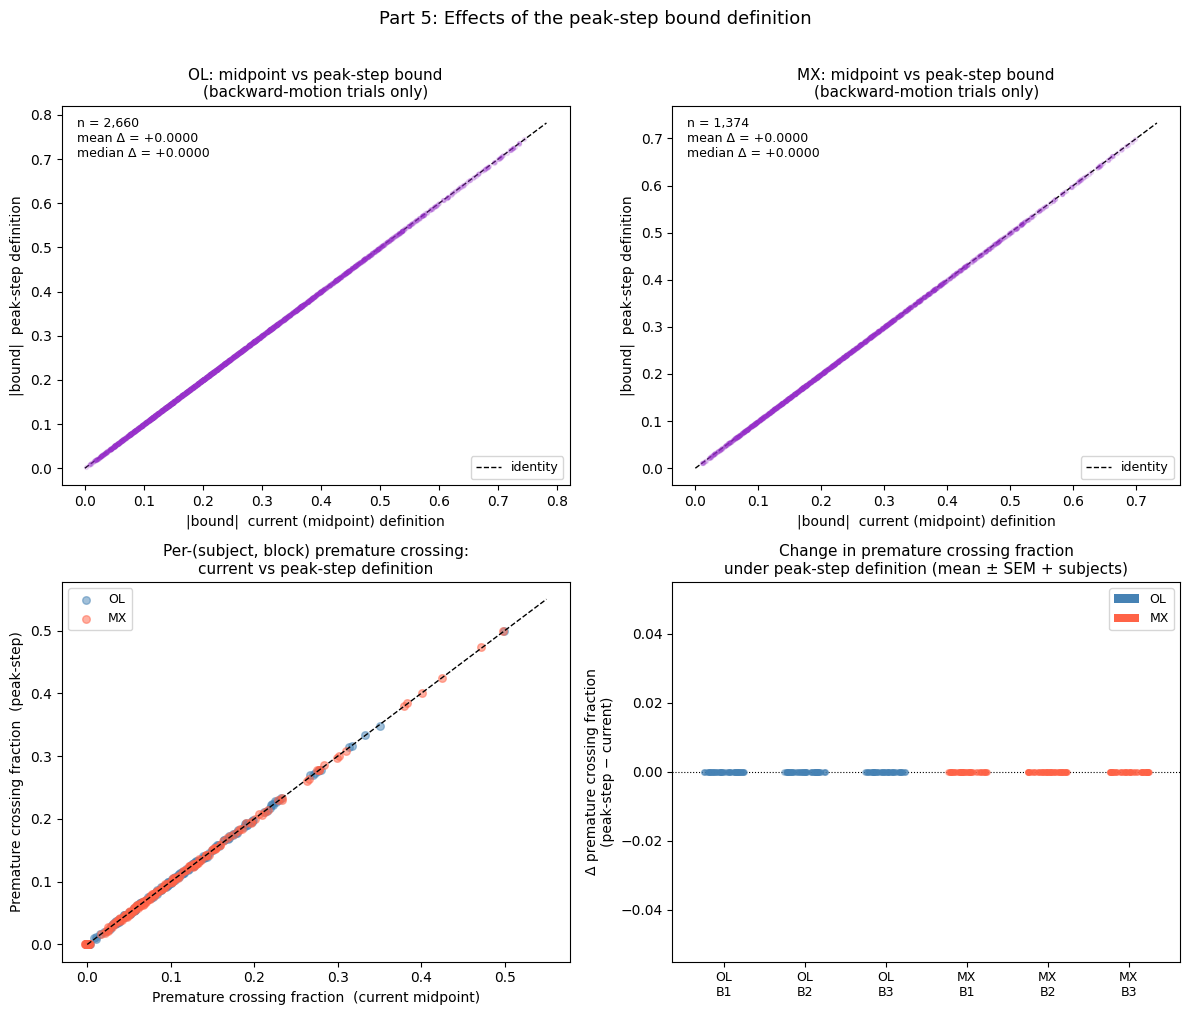

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panels (0,0) and (0,1): |bound_current| vs |bound_peak|, one panel per task ─
for ti, task_type in enumerate(TASK_LIST):
    ax = axes[0, ti]
    dg = datasets[task_type]

    # Backward-motion trials only (where peak != midpoint)
    mask = dg['direction_forward'] == False
    sub  = dg[mask].dropna(subset=['abs_bound_peak'])
    x    = sub['bound'].abs().values          # current midpoint bound
    y    = sub['abs_bound_peak'].values        # peak-step bound (steps[t_curr-1])

    ax.scatter(x, y, color='darkorchid', alpha=0.15, s=8, zorder=5)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='identity')

    delta = y - x
    ax.text(0.03, 0.97,
            f'n = {len(sub):,}\nmean Δ = {delta.mean():+.4f}\nmedian Δ = {np.median(delta):+.4f}',
            transform=ax.transAxes, fontsize=9, va='top')

    ax.set_xlabel('|bound|  current (midpoint) definition', fontsize=10)
    ax.set_ylabel('|bound|  peak-step definition', fontsize=10)
    ax.set_title(f'{task_type}: midpoint vs peak-step bound\n(backward-motion trials only)',
                 fontsize=11)
    ax.legend(fontsize=9)

# ── Panel (1,0): per-subject-block scatter, frac_early vs frac_early_peak ────
ax = axes[1, 0]
for ti, task_type in enumerate(TASK_LIST):
    summary = summaries[task_type]
    bd  = summary.dropna(subset=['frac_early', 'frac_early_peak'])
    jit = rng.uniform(-0.003, 0.003, size=len(bd))
    ax.scatter(bd['frac_early'] + jit, bd['frac_early_peak'],
               alpha=0.5, s=30, label=task_type, color='steelblue' if task_type == 'OL' else 'tomato')

all_vals = pd.concat(
    [summaries[t][['frac_early', 'frac_early_peak']].dropna() for t in TASK_LIST]
)
lim = max(all_vals.values.max(), 0.01) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Premature crossing fraction  (current midpoint)', fontsize=10)
ax.set_ylabel('Premature crossing fraction  (peak-step)', fontsize=10)
ax.set_title('Per-(subject, block) premature crossing:\ncurrent vs peak-step definition', fontsize=11)
ax.legend(fontsize=9)

# ── Panel (1,1): mean Δ premature-crossing fraction by task and block ─────────
ax = axes[1, 1]
x_tick = 0
tick_positions, tick_labels = [], []
for ti, task_type in enumerate(TASK_LIST):
    summary = summaries[task_type]
    for block in block_list:
        bd = summary[summary['block_index'] == block].dropna(
            subset=['frac_early', 'frac_early_peak'])
        if bd.empty:
            continue
        delta = bd['frac_early_peak'].values - bd['frac_early'].values
        m, se = delta.mean(), stats.sem(delta)
        color = 'steelblue' if task_type == 'OL' else 'tomato'
        ax.bar(x_tick, m, yerr=se, color=color, width=0.7, capsize=4,
               ecolor='gray', label=task_type if block == 1 else '_')
        jit = rng.uniform(-0.25, 0.25, size=len(delta))
        ax.scatter(x_tick + jit, delta, color=color, alpha=0.4, s=15, zorder=5)
        tick_positions.append(x_tick)
        tick_labels.append(f'{task_type}\nB{block}')
        x_tick += 1

ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('Δ premature crossing fraction\n(peak-step − current)', fontsize=10)
ax.set_title('Change in premature crossing fraction\nunder peak-step definition (mean ± SEM + subjects)',
             fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('Part 5: Effects of the peak-step bound definition',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Part 6 – Congruence comparison across three bound definitions

We compare the per-subject congruence (fraction of trials where the bound estimate has the
correct sign relative to the animal's choice) produced by three crossing definitions:

- **Def 1 – Basic midpoint**: `(steps[t_curr−1] + steps[t_curr]) / 2` for every trial —
  the signed average of the two raw step positions at the NDT crossing window.
- **Def 2 – Peak-step** (Part 5): midpoint for forward-motion trials; `steps[t_curr−1]`
  (the outermost/earlier step) for backward-motion trials. For backward trials the pigeon
  has already retreated, so using the earlier step avoids the sign flip that can occur when
  the midpoint crosses zero.
- **Def 3 – Refined crossing** (Part 4): midpoint for forward-motion trials; for backward
  trials, the midpoint at the most recent earlier step where the pigeon was above the bound
  **and** moving toward the choice side. Trials with no such recoverable crossing contribute
  NaN, so Def 3 per-subject means are computed over a slightly smaller trial set.

**How congruences are computed.** All three use raw (non-bias-corrected) step positions,
so the comparison reflects only the geometric difference between the definitions:

| trial type | Def 1 | Def 2 | Def 3 |
|---|---|---|---|
| forward at NDT crossing | `sign(midpoint)` | `sign(midpoint)` | `sign(midpoint)` |
| backward, alt crossing found | `sign(midpoint)` | `sign(sc[t_curr−1])` | `sign(alt midpoint)` |
| backward, no alt crossing | `sign(midpoint)` | `sign(sc[t_curr−1])` | NaN |

Def 1 and Def 2 agree on all forward trials and on backward trials where the midpoint and the
earlier step share the same sign. They differ only when the pigeon retreats so far that the
midpoint crosses zero even though `steps[t_curr−1]` is on the correct side.

Each panel shows one block of the OL dataset. Within each block, two scatter plots compare
Def 1 vs Def 2 (left) and Def 1 vs Def 3 (right). Each point is one subject. Points **above
the diagonal** indicate that the alternative definition gives higher congruence for that subject.
The definition that consistently sits above the diagonal should be used for all other analyses.

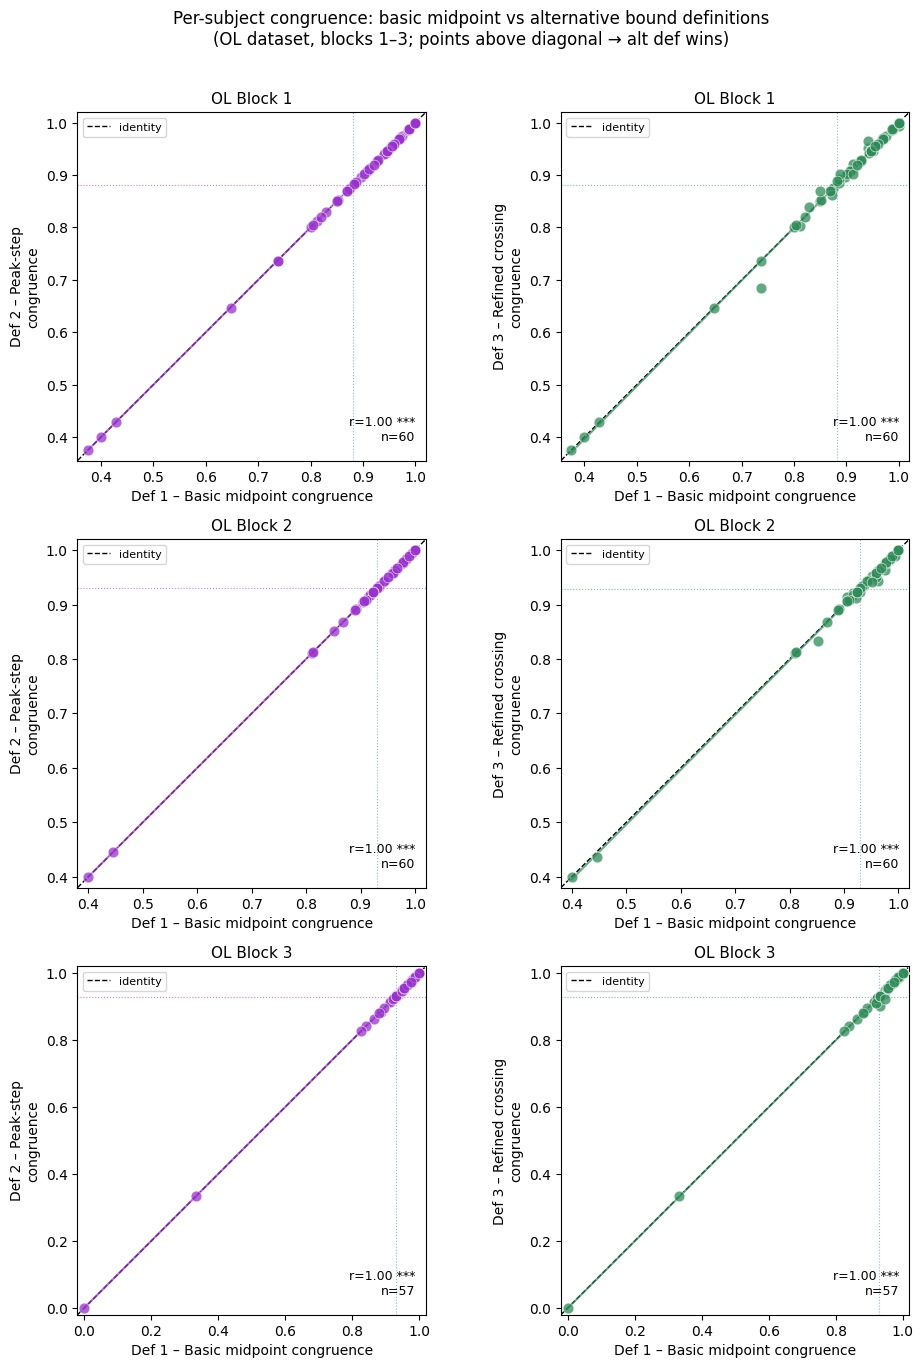

In [9]:
summary_ol = summaries['OL']

comparisons = [
    ('mean_cong_basic', 'mean_cong_peak',    'Def 2 – Peak-step',     'darkorchid'),
    ('mean_cong_basic', 'mean_cong_refined', 'Def 3 – Refined crossing', 'seagreen'),
]

fig, axes = plt.subplots(n_blocks, 2, figsize=(10, 4.5 * n_blocks))

for bi, block in enumerate(block_list):
    bd = summary_ol[summary_ol['block_index'] == block]

    for ci, (xcol, ycol, ylabel, color) in enumerate(comparisons):
        ax  = axes[bi, ci]
        sub = bd.dropna(subset=[xcol, ycol])

        ax.scatter(sub[xcol], sub[ycol], color=color, alpha=0.75, s=60, zorder=5,
                   edgecolors='white', linewidths=0.5)

        # Identity line spanning the full data range
        all_vals = pd.concat([sub[xcol], sub[ycol]])
        lo, hi   = all_vals.min() - 0.02, all_vals.max() + 0.02
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='identity')

        # Regression line
        if len(sub) >= 3:
            sl, ic, r, p, _ = stats.linregress(sub[xcol], sub[ycol])
            xf  = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
            ax.plot(xf, sl * xf + ic, color=color, lw=1.5, alpha=0.7)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
            ax.text(0.97, 0.05, f'r={r:.2f} {sig}\nn={len(sub)}',
                    transform=ax.transAxes, fontsize=9, ha='right', va='bottom')

        # Mean congruence annotations
        m_x = sub[xcol].mean()
        m_y = sub[ycol].mean()
        ax.axvline(m_x, color='steelblue', lw=0.8, ls=':', alpha=0.6)
        ax.axhline(m_y, color=color,       lw=0.8, ls=':', alpha=0.6)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal')
        ax.set_xlabel('Def 1 – Basic midpoint congruence', fontsize=10)
        ax.set_ylabel(f'{ylabel}\ncongruence', fontsize=10)
        ax.set_title(f'OL Block {block}', fontsize=11)
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Per-subject congruence: basic midpoint vs alternative bound definitions\n'
             '(OL dataset, blocks 1–3; points above diagonal → alt def wins)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Part 7 – Incongruence as a function of decision time

For each trial, the **basic midpoint** bound (Def 1) is used to classify congruence. We ask:
do trials with very short decision times account for a disproportionate share of incongruent
trials? A strong DT dependence would suggest that incongruence is driven largely by trials
where the pigeon had little time to move toward the choice side before the NDT window.

Each panel shows one OL block. Each point is one subject at one DT value. The shaded band is
mean ± SEM across subjects at each integer DT (minimum 3 subjects).

- **Top row – counts**: total number of incongruent trials per (subject, DT). Confounded by
  trial-count: DTs with many trials naturally contribute more incongruent trials even if the
  rate is constant.
- **Bottom row – rates**: fraction of incongruent trials per (subject, DT) = count / total.
  Removes the trial-count confound and directly shows how likely an incongruent trial is as
  a function of DT.

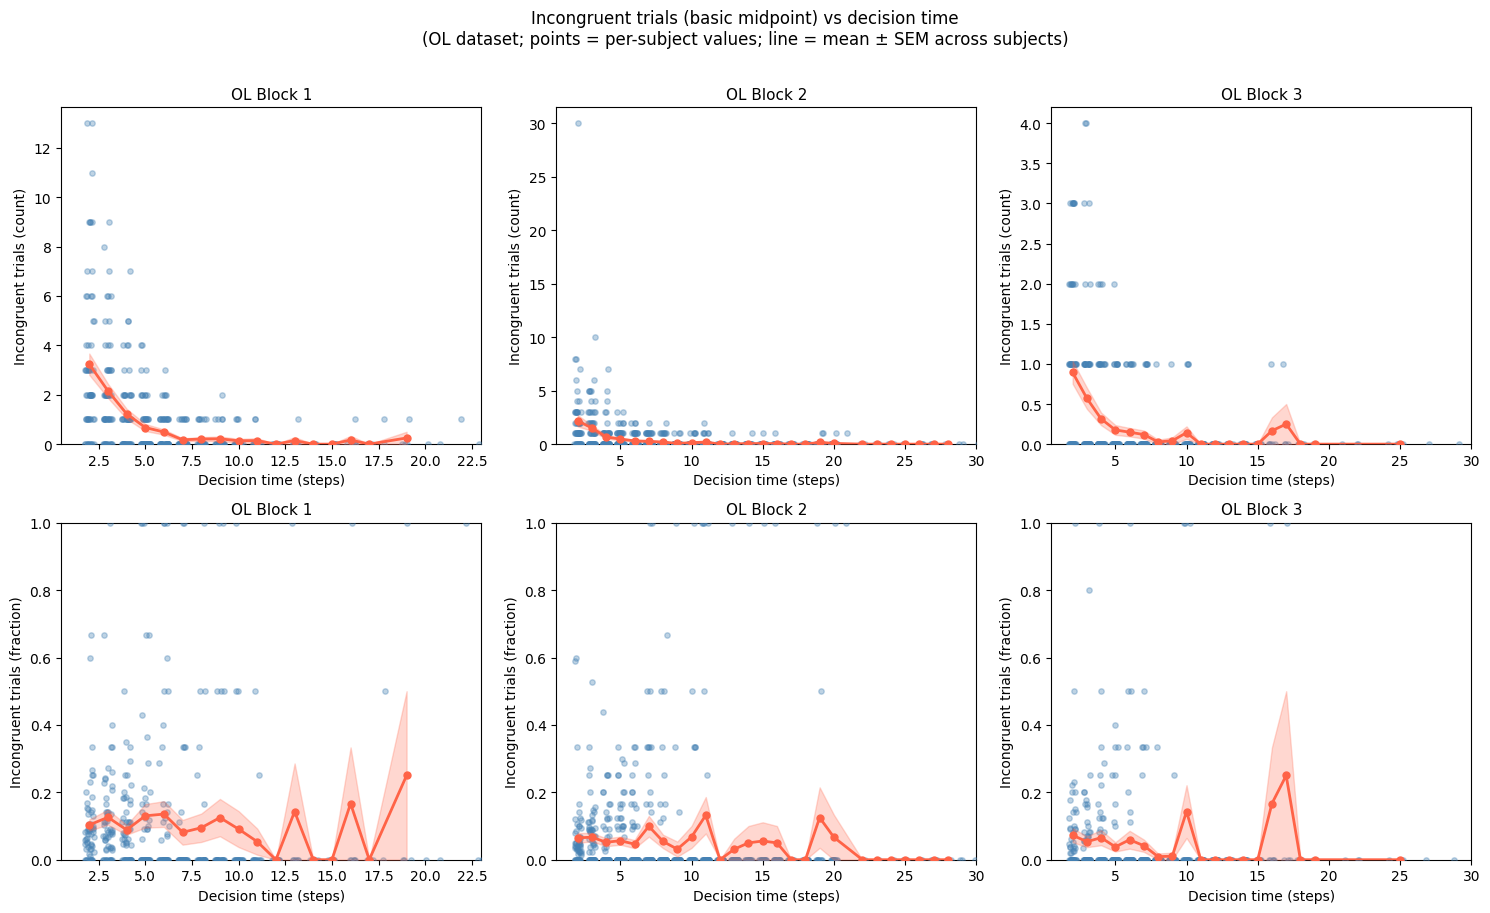

In [10]:
rng7 = np.random.default_rng(7)
dg_ol = datasets['OL']

# Per-(subject, block, DT): count and rate of incongruent trials (basic midpoint)
incong_dt = (
    dg_ol[dg_ol['cong_basic'].notna()]
    .groupby(['subject_index', 'block_index', 'DT'])
    .agg(
        n_incong = ('cong_basic', lambda x: (x == 0).sum()),
        n_total  = ('cong_basic', 'count'),
    )
    .reset_index()
)
incong_dt['rate_incong'] = incong_dt['n_incong'] / incong_dt['n_total']

rows = [
    ('n_incong',    'Incongruent trials (count)',    False),
    ('rate_incong', 'Incongruent trials (fraction)', True),
]

fig, axes = plt.subplots(2, n_blocks, figsize=(5 * n_blocks, 9))

for ri, (ycol, ylabel, is_rate) in enumerate(rows):
    for bi, block in enumerate(block_list):
        ax = axes[ri, bi]
        bd = incong_dt[incong_dt['block_index'] == block]

        dt_max  = int(np.percentile(bd['DT'].values, 99)) if len(bd) else 20
        dt_plot = np.arange(2, dt_max + 1)

        jit = rng7.uniform(-0.25, 0.25, size=len(bd))
        ax.scatter(bd['DT'] + jit, bd[ycol],
                   color='steelblue', alpha=0.35, s=15, zorder=4)

        means, sems, dt_ticks = [], [], []
        for dt in dt_plot:
            vals = bd.loc[bd['DT'] == dt, ycol].values
            if len(vals) >= 3:
                means.append(vals.mean())
                sems.append(stats.sem(vals))
                dt_ticks.append(dt)

        if dt_ticks:
            means = np.array(means)
            sems  = np.array(sems)
            ax.plot(dt_ticks, means, 'o-', color='tomato', lw=2, ms=5, zorder=6)
            ax.fill_between(dt_ticks, means - sems, means + sems,
                            color='tomato', alpha=0.25, zorder=5)

        ax.set_xlabel('Decision time (steps)', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'OL Block {block}', fontsize=11)
        ax.set_xlim(0.5, dt_max + 1)
        ax.set_ylim(0, 1 if is_rate else None)

fig.suptitle('Incongruent trials (basic midpoint) vs decision time\n'
             '(OL dataset; points = per-subject values; line = mean ± SEM across subjects)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Part 8 – Bound magnitude and incongruence (OL, blocks 1–3)

**Figure 1 – Median abs bound (peak-step) on incongruent vs congruent trials (one point per participant):**
Uses peak-step bound (`abs_bound`) and peak-step congruence (`cong_peak`). For each participant,
compute the median `abs_bound` on congruent and incongruent trials separately. Points below the
diagonal → incongruent trials had smaller bound (NDT jitter prediction). Wilcoxon signed-rank
test on paired per-subject medians; exact p-value annotated.

**Figure 2 – Incongruent fraction vs peak-step bound (actual value bins):**
For each participant and each 0.05-wide bin of peak-step bound, the fraction of trials where
the basic midpoint is on the wrong side. Each participant contributes one point per bin
(minimum 5 trials). Red line = mean ± SEM across participants. NDT jitter + fixed threshold
predicts a monotonic decline.

**Figure 3 – Premature crossing fraction vs peak-step bound (actual value bins):**
Same structure as Figure 2 but y = fraction premature crossings (peak-step definition). At
small bounds the threshold is low, making earlier-step exceedances more likely; at large bounds
the threshold is high. Comparing the shape of this curve to Figure 2 reveals how much of the
incongruence at each bound level is attributable to premature crossings.

**Figure 4 – Fraction incongruent vs fraction premature crossings (one point per participant):**
Direct per-participant comparison across blocks. If NDT jitter is the primary source of
incongruence, participants with more premature crossings should also be more incongruent.
Spearman ρ and exact p-value annotated.

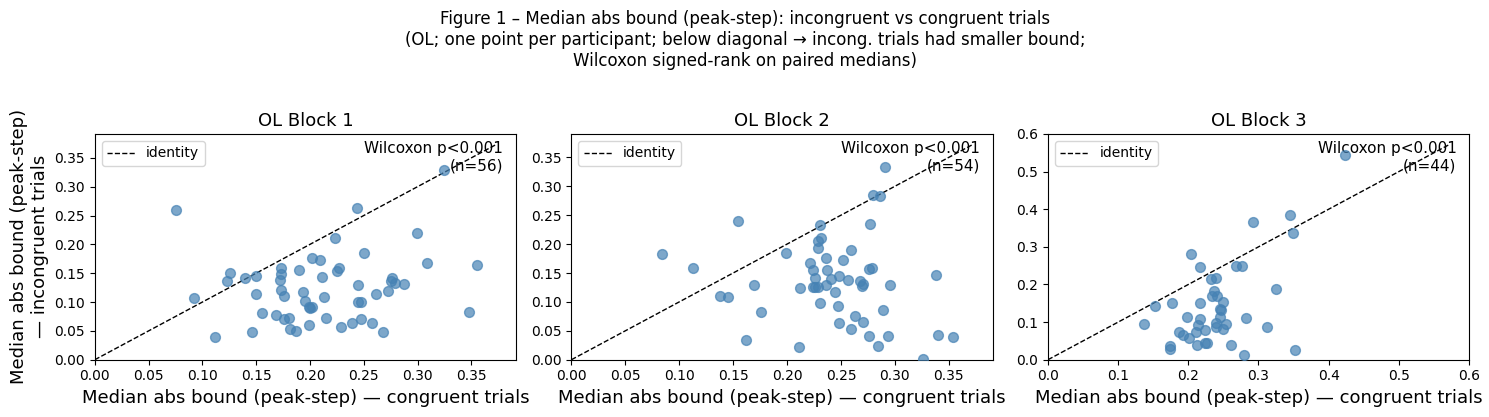

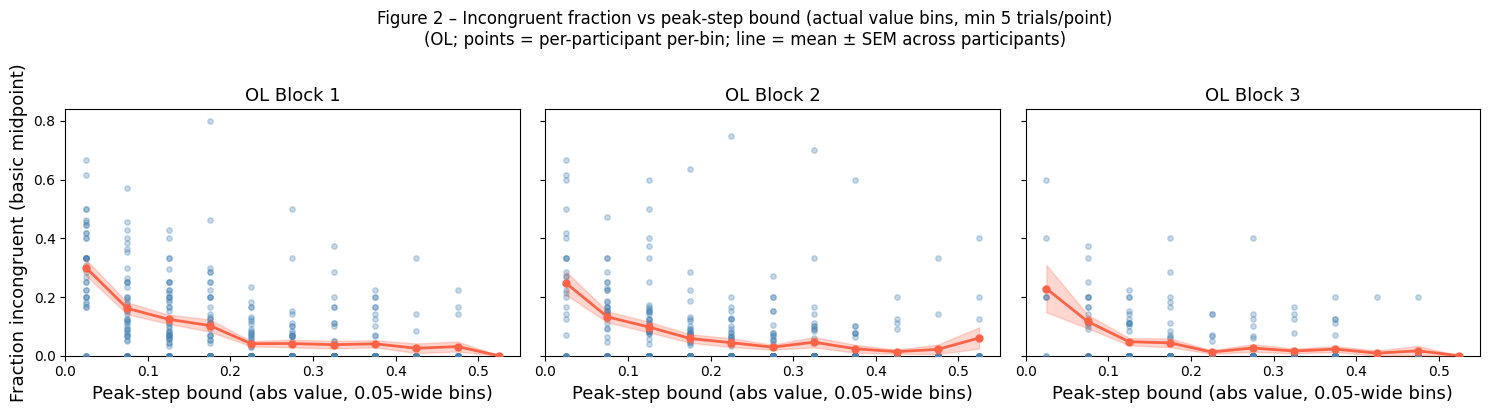

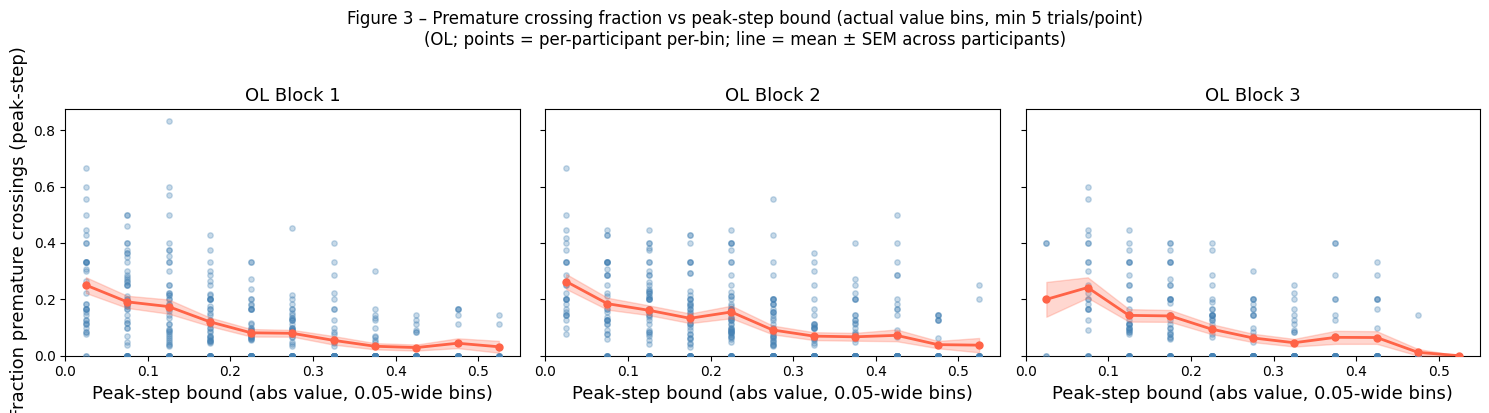

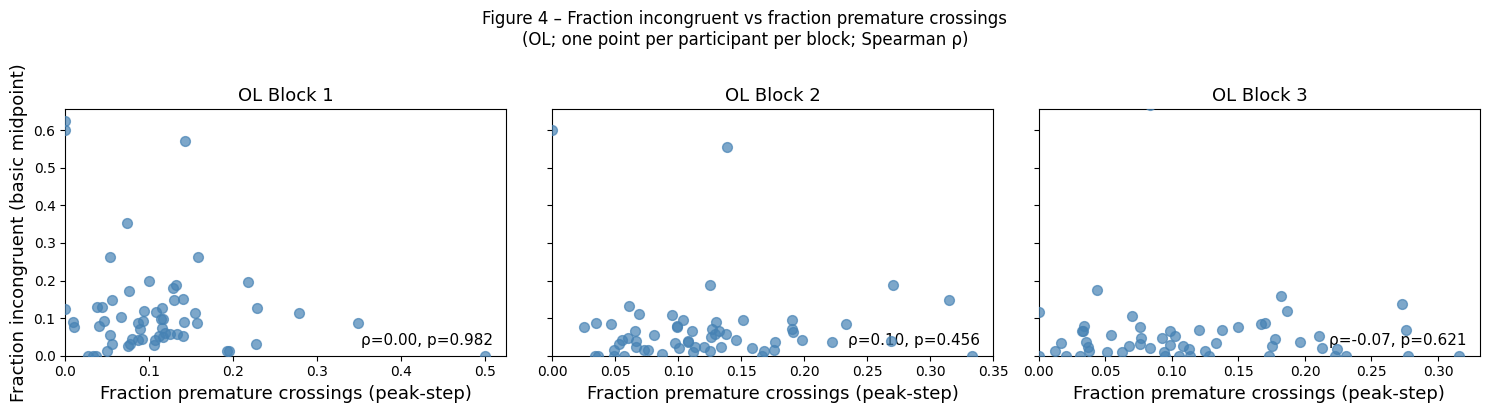

In [11]:
dg8    = datasets['OL'].copy()
sum_ol = summaries['OL']

def _fmt_p(p):
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

BIN_EDGES  = np.arange(0, 0.60, 0.05)
BIN_CENTS  = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
MIN_TRIALS = 5
FS_LABEL   = 13   # axis label font size
FS_TITLE   = 13   # panel title font size
FS_ANNOT   = 11   # in-panel annotation font size


# ── Figure 1: Median abs bound (peak-step) on incong vs cong trials ────────────
fig1, axes1 = plt.subplots(1, n_blocks, figsize=(5 * n_blocks, 4))
for bi, block in enumerate(block_list):
    ax = axes1[bi]
    bd = dg8[(dg8['block_index'] == block)
             & dg8['cong_peak'].notna() & dg8['abs_bound'].notna()]
    cong_meds, incong_meds = [], []
    for subj in bd['subject_index'].unique():
        sd = bd[bd['subject_index'] == subj]
        mc = sd.loc[sd['cong_peak'] == 1, 'abs_bound'].median()
        mi = sd.loc[sd['cong_peak'] == 0, 'abs_bound'].median()
        if np.isfinite(mc) and np.isfinite(mi):
            cong_meds.append(mc)
            incong_meds.append(mi)
    if cong_meds:
        x, y = np.array(cong_meds), np.array(incong_meds)
        ax.scatter(x, y, color='steelblue', alpha=0.7, s=50, zorder=5)
        lim = max(x.max(), y.max()) * 1.05
        ax.plot([0, lim], [0, lim], 'k--', lw=1, label='identity')
        if len(x) >= 3:
            _, p = stats.wilcoxon(x, y)
            ax.text(0.97, 0.97, f'Wilcoxon {_fmt_p(p)}\n(n={len(x)})',
                    transform=ax.transAxes, fontsize=FS_ANNOT, ha='right', va='top')
        ax.set_xlim(left=0); ax.set_ylim(bottom=0)
        ax.legend(fontsize=FS_ANNOT - 1)
    ax.set_xlabel('Median abs bound (peak-step) — congruent trials', fontsize=FS_LABEL)
    if bi == 0:
        ax.set_ylabel('Median abs bound (peak-step)\n— incongruent trials', fontsize=FS_LABEL)
    ax.set_title(f'OL Block {block}', fontsize=FS_TITLE)

fig1.suptitle('Figure 1 – Median abs bound (peak-step): incongruent vs congruent trials\n'
              '(OL; one point per participant; below diagonal → incong. trials had smaller bound;\n'
              'Wilcoxon signed-rank on paired medians)',
              fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


# ── Helper: binned per-participant fractions ───────────────────────────────────
def _binned_fracs(bd, ycol):
    all_x, all_y = [], []
    bin_vals     = [[] for _ in BIN_CENTS]
    for subj in bd['subject_index'].unique():
        sd = bd[bd['subject_index'] == subj]
        for k, (lo, hi) in enumerate(zip(BIN_EDGES[:-1], BIN_EDGES[1:])):
            mask = (sd['abs_bound'] >= lo) & (sd['abs_bound'] < hi)
            if mask.sum() >= MIN_TRIALS:
                fv = sd.loc[mask, ycol].mean()
                all_x.append(BIN_CENTS[k]); all_y.append(fv); bin_vals[k].append(fv)
    return all_x, all_y, bin_vals

def _plot_binned(axes, bd_list, ycol, ylabel):
    for bi, (block, bd) in enumerate(zip(block_list, bd_list)):
        ax = axes[bi]
        all_x, all_y, bin_vals = _binned_fracs(bd, ycol)
        if all_x:
            ax.scatter(all_x, all_y, color='steelblue', alpha=0.3, s=15, zorder=4)
        mx, my, ms = [], [], []
        for k, cent in enumerate(BIN_CENTS):
            vals = bin_vals[k]
            if len(vals) >= 3:
                mx.append(cent); my.append(np.mean(vals)); ms.append(stats.sem(vals))
        if mx:
            my_a, ms_a = np.array(my), np.array(ms)
            ax.plot(mx, my_a, 'o-', color='tomato', lw=2, ms=5, zorder=6)
            ax.fill_between(mx, my_a - ms_a, my_a + ms_a, color='tomato', alpha=0.25, zorder=5)
        ax.set_xlabel('Peak-step bound (abs value, 0.05-wide bins)', fontsize=FS_LABEL)
        if bi == 0:
            ax.set_ylabel(ylabel, fontsize=FS_LABEL)
        ax.set_title(f'OL Block {block}', fontsize=FS_TITLE)
        ax.set_xlim(BIN_EDGES[0], BIN_EDGES[-1])
        ax.set_ylim(bottom=0)


# ── Figure 2: Incongruent fraction vs peak-step bound bins ────────────────────
dg8['_incong'] = (dg8['cong_basic'] == 0).astype(float)
bd_by_block2 = [
    dg8[(dg8['block_index'] == b) & dg8['cong_basic'].notna() & dg8['abs_bound'].notna()]
    for b in block_list
]
fig2, axes2 = plt.subplots(1, n_blocks, figsize=(5 * n_blocks, 4), sharey=True)
_plot_binned(axes2, bd_by_block2, '_incong', 'Fraction incongruent (basic midpoint)')
fig2.suptitle(
    f'Figure 2 – Incongruent fraction vs peak-step bound (actual value bins, min {MIN_TRIALS} trials/point)\n'
    '(OL; points = per-participant per-bin; line = mean ± SEM across participants)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


# ── Figure 3: Premature crossing fraction vs peak-step bound bins ──────────────
bd_by_block3 = [
    dg8[(dg8['block_index'] == b) & dg8['early_crossing_peak'].notna() & dg8['abs_bound'].notna()]
    for b in block_list
]
fig3, axes3 = plt.subplots(1, n_blocks, figsize=(5 * n_blocks, 4), sharey=True)
_plot_binned(axes3, bd_by_block3, 'early_crossing_peak',
             'Fraction premature crossings (peak-step)')
fig3.suptitle(
    f'Figure 3 – Premature crossing fraction vs peak-step bound (actual value bins, min {MIN_TRIALS} trials/point)\n'
    '(OL; points = per-participant per-bin; line = mean ± SEM across participants)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


# ── Figure 4: Fraction incongruent vs fraction premature crossings ─────────────
fig4, axes4 = plt.subplots(1, n_blocks, figsize=(5 * n_blocks, 4), sharey=True)
for bi, block in enumerate(block_list):
    ax = axes4[bi]
    bd = sum_ol[(sum_ol['block_index'] == block)].dropna(
             subset=['mean_cong_basic', 'frac_early_peak'])
    x  = bd['frac_early_peak'].values
    y  = (1 - bd['mean_cong_basic'].values)
    ax.scatter(x, y, color='steelblue', alpha=0.7, s=50, zorder=5)
    if len(x) >= 3:
        rho, p = stats.spearmanr(x, y)
        ax.text(0.97, 0.03, f'ρ={rho:.2f}, {_fmt_p(p)}',
                transform=ax.transAxes, fontsize=FS_ANNOT, ha='right', va='bottom')
    ax.set_xlabel('Fraction premature crossings (peak-step)', fontsize=FS_LABEL)
    if bi == 0:
        ax.set_ylabel('Fraction incongruent (basic midpoint)', fontsize=FS_LABEL)
    ax.set_title(f'OL Block {block}', fontsize=FS_TITLE)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

fig4.suptitle('Figure 4 – Fraction incongruent vs fraction premature crossings\n'
              '(OL; one point per participant per block; Spearman ρ)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()